
## preprocessing
The dataset was first loaded and inspected to understand its structure, data types, and size.

Duplicate records were removed to prevent biased learning and repeated observations.

The target variable default payment next month was renamed to default for clarity.

The ID column was dropped since it serves only as an identifier and has no predictive value.

Invalid categories in EDUCATION and MARRIAGE were grouped into an “Other” category to ensure data consistency.

The cleaned dataset was prepared for exploratory data analysis and modeling.

In [1]:
import pandas as pd
import numpy as np
# Load the Excel dataset (header=1 is used because first row contains a description/title)
df = pd.read_excel("default of credit card clients.xls", header=1)

# Preview first 5 rows
df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [2]:
# Check dataset size and column types
print("Rows, Columns:", df.shape)
df.info()

# Check missing values
print("\nMissing values per column:\n", df.isnull().sum())


Rows, Columns: (30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 

In [3]:
# Remove duplicate rows if any
df.drop_duplicates(inplace=True)

# Rename target column for convenience
df.rename(columns={"default payment next month": "default"}, inplace=True)

# Drop ID column (identifier, not useful for prediction)
df.drop(columns=["ID"], inplace=True)

# Check dataset shape after cleaning
print("Shape after removing duplicates and ID:", df.shape)


Shape after removing duplicates and ID: (30000, 24)


In [4]:
# EDUCATION: Replace invalid categories (0, 5, 6) with 'Other' (4)
df["EDUCATION"] = df["EDUCATION"].replace([0, 5, 6], 4)

# MARRIAGE: Replace invalid category (0) with 'Other' (3)
df["MARRIAGE"] = df["MARRIAGE"].replace(0, 3)

# Verify cleaned categories
print("EDUCATION values:", sorted(df["EDUCATION"].unique()))
print("MARRIAGE values:", sorted(df["MARRIAGE"].unique()))


EDUCATION values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE values: [np.int64(1), np.int64(2), np.int64(3)]


The distribution of the target variable was analyzed to understand class imbalance between defaulters and non-defaulters.

A correlation heatmap was used to examine relationships among numerical variables and identify strongly related features.

Repayment status variables were analyzed to study their impact on default behavior.

Credit limit distributions were compared between defaulters and non-defaulters to assess financial risk patterns.

Age distribution was analyzed to explore demographic differences in default behavior.

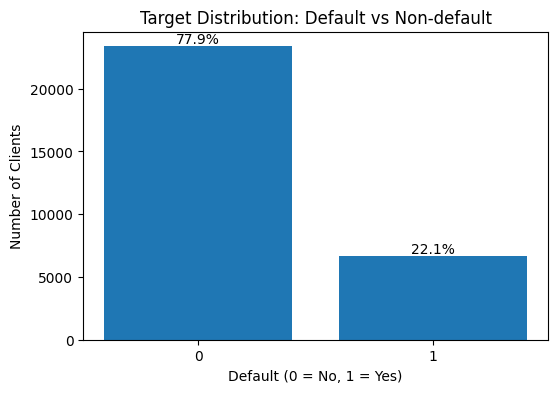

In [5]:
import matplotlib.pyplot as plt

# Count and percentage of classes
counts = df["default"].value_counts()
percent = df["default"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Target Distribution: Default vs Non-default")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Number of Clients")

# Add percentage labels
for i, (c, p) in enumerate(zip(counts.values, percent.values)):
    plt.text(i, c, f"{p:.1f}%", ha="center", va="bottom")

plt.show()


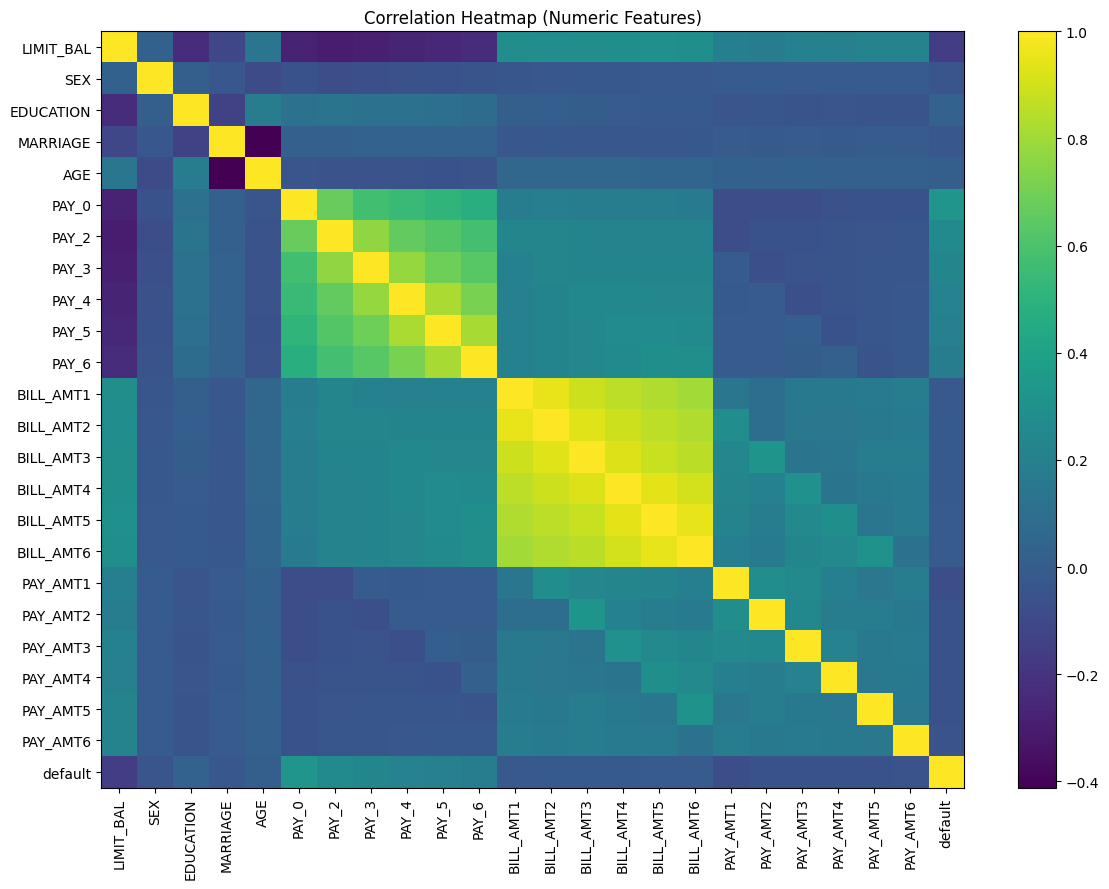

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Correlation matrix (numeric columns only)
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,9))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Correlation Heatmap (Numeric Features)")

# axis labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.tight_layout()
plt.show()


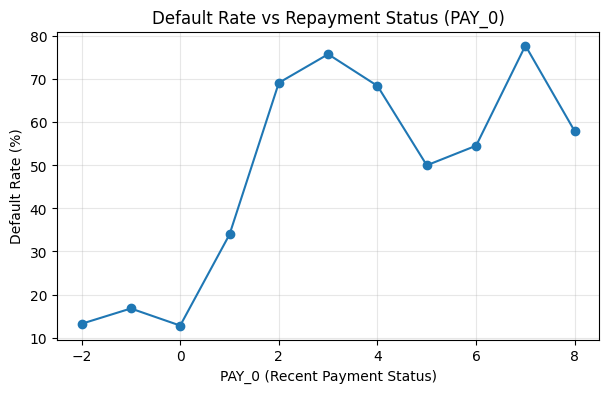

In [7]:
import matplotlib.pyplot as plt

# Default rate by PAY_0
default_rate = df.groupby("PAY_0")["default"].mean().sort_index() * 100

plt.figure(figsize=(7,4))
plt.plot(default_rate.index, default_rate.values, marker="o")
plt.title("Default Rate vs Repayment Status (PAY_0)")
plt.xlabel("PAY_0 (Recent Payment Status)")
plt.ylabel("Default Rate (%)")
plt.grid(True, alpha=0.3)
plt.show()


/tmp/ipython-input-3301568347.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_default, yes_default], labels=["No Default (0)", "Default (1)"])


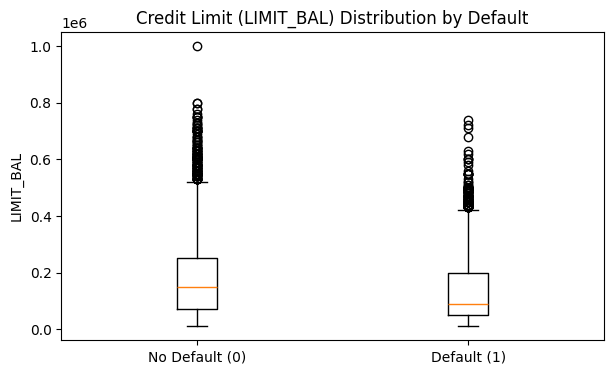

In [8]:
import matplotlib.pyplot as plt

# Prepare data
no_default = df[df["default"] == 0]["LIMIT_BAL"]
yes_default = df[df["default"] == 1]["LIMIT_BAL"]

plt.figure(figsize=(7,4))
plt.boxplot([no_default, yes_default], labels=["No Default (0)", "Default (1)"])
plt.title("Credit Limit (LIMIT_BAL) Distribution by Default")
plt.ylabel("LIMIT_BAL")
plt.show()


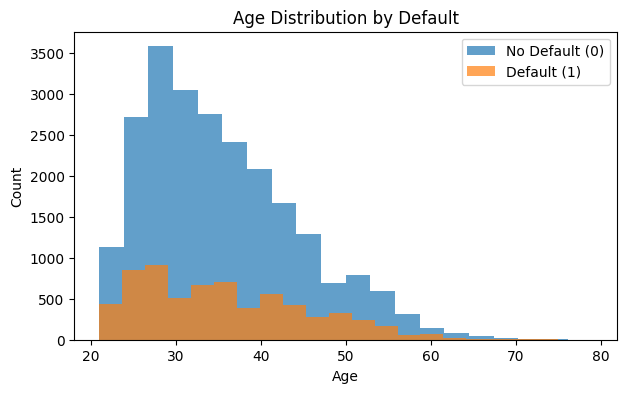

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.hist(df[df["default"] == 0]["AGE"], bins=20, alpha=0.7, label="No Default (0)")
plt.hist(df[df["default"] == 1]["AGE"], bins=20, alpha=0.7, label="Default (1)")

plt.title("Age Distribution by Default")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()


## Train–Test Split, Feature Scaling, and Class Imbalance Handling
The dataset was split into training and testing sets using an 80:20 ratio.

Stratified sampling was applied to preserve the proportion of defaulters and non-defaulters in both sets.

Feature scaling was performed using StandardScaler to standardize numerical variables.

The scaler was fitted only on the training data and then applied to the testing data to avoid data leakage.

Due to class imbalance in the target variable, SMOTE was applied to the training dataset.

SMOTE generated synthetic samples for the minority class, improving class balance and model learning.

The test dataset was left unchanged and used solely for final model evaluation.


In [10]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop("default", axis=1)
y = df["default"]

# Train-test split (stratify keeps class ratio same in train/test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)
print("\nTarget distribution (Train):\n", y_train.value_counts(normalize=True))
print("\nTarget distribution (Test):\n", y_test.value_counts(normalize=True))



Train shape: (24000, 23) (24000,)
Test shape : (6000, 23) (6000,)

Target distribution (Train):
 default
0    0.778792
1    0.221208
Name: proportion, dtype: float64

Target distribution (Test):
 default
0    0.778833
1    0.221167
Name: proportion, dtype: float64


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")


Scaling completed.


In [12]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to the TRAINING data (never on test data)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_train_smote).value_counts())


Before SMOTE:
 default
0    18691
1     5309
Name: count, dtype: int64

After SMOTE:
 default
0    18691
1    18691
Name: count, dtype: int64



## Baseline Models
Baseline versions of Random Forest, XGBoost, and Artificial Neural Network (ANN) were first trained using default or minimally adjusted hyperparameters.

The purpose of training baseline models was to establish a reference point for model performance.

These initial models helped in understanding the learning behavior of each algorithm on the dataset.

Performance results from baseline models were later used to assess the impact of hyperparameter tuning.

Using baseline models ensures a fair comparison between untuned and tuned versions of the algorithms.

In [13]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=200,        # number of trees
    random_state=42,         # reproducibility
    class_weight="balanced", # extra support for imbalance
    n_jobs=-1                # use all CPU cores
)

# Train model on SMOTE-balanced training data
rf_model.fit(X_train_smote, y_train_smote)

# Predict class labels on scaled test data
y_pred_rf = rf_model.predict(X_test_scaled)

# Predict probabilities for ROC-AUC score
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Print results
print("Random Forest Results")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest Results
Accuracy : 0.7948333333333333
Precision: 0.5418118466898955
Recall   : 0.4687264506405426
F1-score : 0.5026262626262626
ROC-AUC  : 0.7503051489008915

Confusion Matrix:
 [[4147  526]
 [ 705  622]]


In [14]:
# XGBoost Classifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Initialize model
xgb_model = XGBClassifier(
    n_estimators=300,         # boosting rounds
    learning_rate=0.05,       # step size
    max_depth=4,              # tree depth
    subsample=0.9,            # row sampling
    colsample_bytree=0.9,     # feature sampling
    random_state=42,
    eval_metric="logloss"     # avoids warning
)

# Train model on SMOTE-balanced training data
xgb_model.fit(X_train_smote, y_train_smote)

# Predict class labels on scaled test data
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Predict probabilities for ROC-AUC score
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Print results
print("XGBoost Results")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1-score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))


XGBoost Results
Accuracy : 0.7961666666666667
Precision: 0.5456140350877193
Recall   : 0.4687264506405426
F1-score : 0.5042561815970815
ROC-AUC  : 0.764648880814298

Confusion Matrix:
 [[4155  518]
 [ 705  622]]


In [15]:
# Artificial Neural Network (ANN)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Build ANN model
ann_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_smote.shape[1],)),  # input layer
    Dropout(0.3),                                                         # reduce overfitting
    Dense(32, activation="relu"),                                         # hidden layer
    Dropout(0.2),                                                         # reduce overfitting
    Dense(1, activation="sigmoid")                                        # output layer for binary class
])

# Compile model
ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train ANN on SMOTE-balanced training data
history = ann_model.fit(
    X_train_smote,
    y_train_smote,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Predict probabilities on scaled test data
y_prob_ann = ann_model.predict(X_test_scaled).ravel()

# Convert probabilities to class labels (0/1) using threshold 0.5
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

# Print results
print("ANN Results")
print("Accuracy :", accuracy_score(y_test, y_pred_ann))
print("Precision:", precision_score(y_test, y_pred_ann))
print("Recall   :", recall_score(y_test, y_pred_ann))
print("F1-score :", f1_score(y_test, y_pred_ann))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_ann))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ann))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
935/935 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7011 - loss: 0.6056 - val_accuracy: 0.4971 - val_loss: 0.7579
Epoch 2/20
935/935 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7398 - loss: 0.5602 - val_accuracy: 0.4748 - val_loss: 0.7584
Epoch 3/20
935/935 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7431 - loss: 0.5509 - val_accuracy: 0.4848 - val_loss: 0.7986
Epoch 4/20
935/935 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7476 - loss: 0.5435 - val_accuracy: 0.4793 - val_loss: 0.7863
Epoch 5/20
935/935 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7468 - loss: 0.5348 - val_accuracy: 0.5477 - val_loss: 0.7237
Epoch 6/20
935/935 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7459 - loss: 0.5372 - val_accuracy: 0.5069 - val_loss: 0.7614
Epoch 7/20
935/935 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7478 - loss: 0.5363 - val_accuracy: 0.5069 - val_loss: 0.7687
Epoch 8/20
935/935 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7444 - loss: 0.5377 - val_accuracy: 0.

In [16]:
from sklearn.metrics import classification_report

print("=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf))

print("\n=== XGBoost Classification Report ===")
print(classification_report(y_test, y_pred_xgb))

print("\n=== ANN Classification Report ===")
print(classification_report(y_test, y_pred_ann))


=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      4673
           1       0.54      0.47      0.50      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.68      0.69      6000
weighted avg       0.79      0.79      0.79      6000


=== XGBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      4673
           1       0.55      0.47      0.50      1327

    accuracy                           0.80      6000
   macro avg       0.70      0.68      0.69      6000
weighted avg       0.79      0.80      0.79      6000


=== ANN Classification Report ===
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      4673
           1       0.55      0.50      0.52      1327

    accuracy                           0.80      6000
   macro a

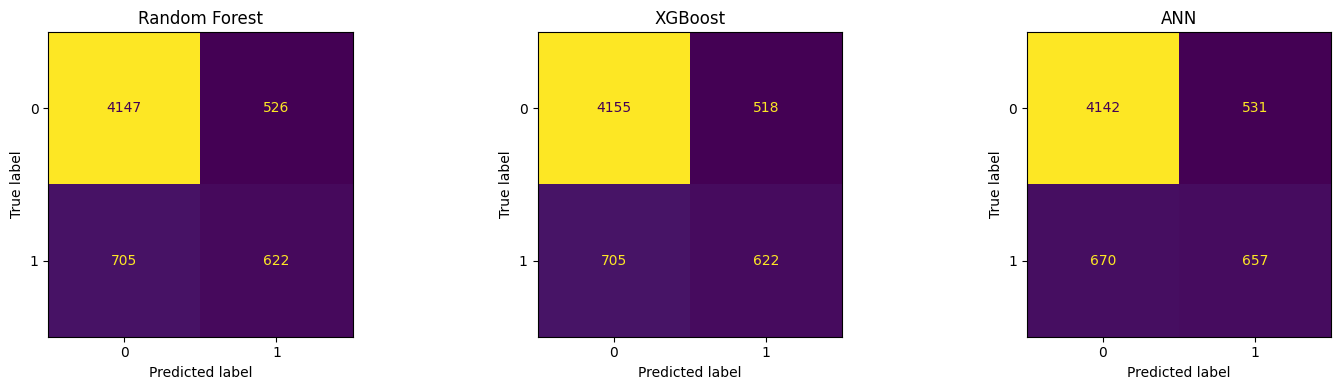

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, ax=axes[0], colorbar=False
)
axes[0].set_title("Random Forest")

# XGBoost
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb, ax=axes[1], colorbar=False
)
axes[1].set_title("XGBoost")

# ANN
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_ann, ax=axes[2], colorbar=False
)
axes[2].set_title("ANN")

plt.tight_layout()
plt.show()


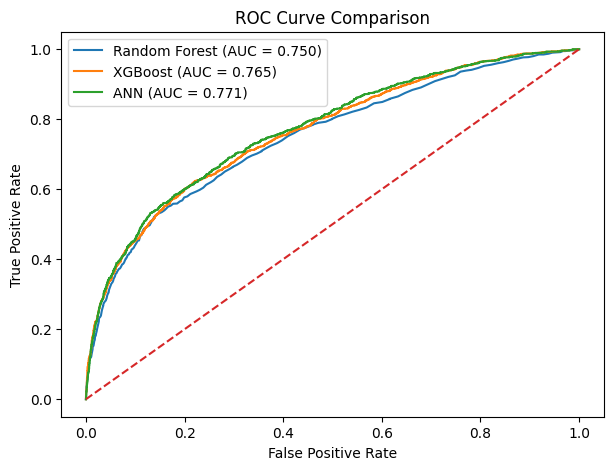

In [18]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_ann)

# Compute AUC scores
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_ann = auc(fpr_ann, tpr_ann)

# Plot ROC curves
plt.figure(figsize=(7,5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot(fpr_ann, tpr_ann, label=f"ANN (AUC = {auc_ann:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score

# Base model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Small search space (kept minimal)
rf_params = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Randomized search with ROC-AUC scoring
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit on SMOTE training data
rf_search.fit(X_train_smote, y_train_smote)

print("Best Random Forest Params:", rf_search.best_params_)
print("Best CV ROC-AUC:", rf_search.best_score_)

# Evaluate best model on test set
best_rf = rf_search.best_estimator_
rf_prob_tuned = best_rf.predict_proba(X_test_scaled)[:, 1]
print("Test ROC-AUC (Tuned RF):", roc_auc_score(y_test, rf_prob_tuned))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Random Forest Params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}
Best CV ROC-AUC: 0.9301315315669936
Test ROC-AUC (Tuned RF): 0.7528380984510579


In [20]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score

# Base model
xgb = XGBClassifier(random_state=42, eval_metric="logloss")

# Small search space (kept minimal)
xgb_params = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

# Randomized search with ROC-AUC scoring
xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=10,              # small number of tries
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit on SMOTE training data
xgb_search.fit(X_train_smote, y_train_smote)

print("Best XGBoost Params:", xgb_search.best_params_)
print("Best CV ROC-AUC:", xgb_search.best_score_)

# Evaluate best model on test set
best_xgb = xgb_search.best_estimator_
xgb_prob_tuned = best_xgb.predict_proba(X_test_scaled)[:, 1]
print("Test ROC-AUC (Tuned XGB):", roc_auc_score(y_test, xgb_prob_tuned))


Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best XGBoost Params: {'subsample': 0.9, 'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV ROC-AUC: 0.9250236184980023
Test ROC-AUC (Tuned XGB): 0.7600874107069568


In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import roc_auc_score

# Function to build ANN with variable units and dropout
def build_ann(units=64, dropout=0.3):
    model = Sequential([
        Dense(units, activation="relu", input_shape=(X_train_smote.shape[1],)),
        Dropout(dropout),
        Dense(units // 2, activation="relu"),
        Dropout(dropout / 2),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy")
    return model

# Small tuning options (minimal)
units_list = [32, 64]
dropout_list = [0.2, 0.3]

best_auc = 0
best_params = None
best_ann = None

for units in units_list:
    for dr in dropout_list:
        print(f"\nTraining ANN with units={units}, dropout={dr}")

        ann = build_ann(units=units, dropout=dr)
        ann.fit(X_train_smote, y_train_smote, epochs=10, batch_size=32, verbose=0)

        # Predict probabilities on test set
        y_prob = ann.predict(X_test_scaled).ravel()
        auc_score = roc_auc_score(y_test, y_prob)
        print("Test ROC-AUC:", auc_score)

        # Store best model
        if auc_score > best_auc:
            best_auc = auc_score
            best_params = (units, dr)
            best_ann = ann

print("\nBest ANN Params (units, dropout):", best_params)
print("Best ANN Test ROC-AUC:", best_auc)



Training ANN with units=32, dropout=0.2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test ROC-AUC: 0.7692153500580785

Training ANN with units=32, dropout=0.3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test ROC-AUC: 0.7666457939281779

Training ANN with units=64, dropout=0.2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test ROC-AUC: 0.7672036007973462

Training ANN with units=64, dropout=0.3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test ROC-AUC: 0.7713662688267882

Best ANN Params (units, dropout): (64, 0.3)
Best ANN Test ROC-AUC: 0.7713662688267882


In [22]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

# --- Random Forest ---
rf_pred = best_rf.predict(X_test_scaled)
rf_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

results.append({
    "Model": "Random Forest (Tuned)",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1-score": f1_score(y_test, rf_pred),
    "ROC-AUC": roc_auc_score(y_test, rf_prob)
})

# --- XGBoost ---
xgb_pred = best_xgb.predict(X_test_scaled)
xgb_prob = best_xgb.predict_proba(X_test_scaled)[:, 1]

results.append({
    "Model": "XGBoost (Tuned)",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1-score": f1_score(y_test, xgb_pred),
    "ROC-AUC": roc_auc_score(y_test, xgb_prob)
})

# --- ANN ---
ann_prob = best_ann.predict(X_test_scaled).ravel()
ann_pred = (ann_prob >= 0.5).astype(int)

results.append({
    "Model": "ANN (Tuned)",
    "Accuracy": accuracy_score(y_test, ann_pred),
    "Precision": precision_score(y_test, ann_pred),
    "Recall": recall_score(y_test, ann_pred),
    "F1-score": f1_score(y_test, ann_pred),
    "ROC-AUC": roc_auc_score(y_test, ann_prob)
})

# Create results table
results_df = pd.DataFrame(results)

# Round values for neat display
results_df = results_df.round(4)

print("Tuned Model Comparison Table")
results_df


188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Tuned Model Comparison Table


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest (Tuned),0.7963,0.5459,0.4702,0.5053,0.7528
1,XGBoost (Tuned),0.8040,0.5802,0.4115,0.4815,0.7601
2,ANN (Tuned),0.7363,0.4352,0.6451,0.5197,0.7714
